# Credit Card Fraud Detection
**Author:** Faisa Hassan  
**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/kartik2112/fraud-detection)  
**GitHub:** [github.com/faisahassan/fraud-detection](#)

## Problem Statement
Every second, thousands of card transactions are processed globally. A tiny fraction are fraud, but identifying which ones is far from simple. A model that flags everything as legitimate scores 99%+ accuracy and catches zero fraud. This project tackles that problem properly.

The goal is to build a fraud detection pipeline that:
- Handles severe class imbalance without cheating the metrics
- Compares multiple modelling approaches and explains the tradeoffs
- Produces predictions that can be explained — not just made

Explainability is not optional here. In financial services, regulators require justification for automated decisions. A model that says "trust me" is not deployable in production.

## 1. Setup
Standard imports. Key libraries: `imbalanced-learn` for resampling strategies, `xgboost` for gradient boosting, and `shap` for explainability.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import shap
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")


All imports successful


## 2. Load & Explore Data
Before building anything, we need to understand what we're working with — particularly the class distribution, which determines the entire modelling strategy.

In [7]:
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nFraud rate in training data: {train_df['is_fraud'].mean()*100:.2f}%")
print(f"\nColumn names:\n{train_df.columns.tolist()}")

Train shape: (1296675, 23)
Test shape: (555719, 23)

Fraud rate in training data: 0.58%

Column names:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


### The Core Challenge: Class Imbalance
**0.58% of transactions are fraud.** This means a model that predicts "legitimate" for every single transaction would score 99.42% accuracy — and be completely useless in practice.

This is why accuracy is the wrong metric here. Throughout this project we evaluate on **precision, recall, F1, and AUC-ROC** — metrics that actually reflect how well the model finds fraud.

## 3. Preprocessing & Feature Engineering
Raw data rarely speaks directly to the patterns we care about. Beyond cleaning, we engineer features that encode domain knowledge about how fraud actually behaves.

**Key decisions:**
- Extract `trans_hour` and `trans_dayofweek` — fraud patterns differ significantly by time
- Derive `age` from date of birth — cardholder age is a behavioural signal
- Calculate `distance` between cardholder location and merchant — a transaction 500 miles from your registered address is suspicious
- Drop identifier columns (name, card number, address) — these are noise for modelling and privacy risks in a real system

This is different from the naive approach of simply encoding every column and hoping the model figures it out.

In [8]:
def preprocess(df):
    df = df.copy()
    
    # Convert datetime and extract useful features
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour
    df['trans_dayofweek'] = df['trans_date_trans_time'].dt.dayofweek
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
    
    # Distance between cardholder and merchant
    df['distance'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2)
    
    # Drop columns that are identifiers or redundant
    drop_cols = ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'first', 'last',
                 'street', 'city', 'state', 'zip', 'dob', 'trans_num', 'unix_time',
                 'lat', 'long', 'merch_lat', 'merch_long']
    df = df.drop(columns=drop_cols)
    
    # Encode categoricals
    for col in ['merchant', 'category', 'gender', 'job']:
        df[col] = LabelEncoder().fit_transform(df[col])
    
    return df

train_clean = preprocess(train_df)
test_clean = preprocess(test_df)

print("Processed train shape:", train_clean.shape)
print("\nFeatures:", train_clean.columns.tolist())

Processed train shape: (1296675, 11)

Features: ['merchant', 'category', 'amt', 'gender', 'city_pop', 'job', 'is_fraud', 'trans_hour', 'trans_dayofweek', 'age', 'distance']


## 4. Train/Test Split & Scaling
We scale features using `StandardScaler` fit only on training data. This is important — fitting the scaler on test data would constitute data leakage, artificially inflating performance by letting the model "see" the test distribution during training.

In production, you would apply the same saved scaler to every incoming transaction.

In [9]:
X_train = train_clean.drop(columns=['is_fraud'])
y_train = train_clean['is_fraud']

X_test = test_clean.drop(columns=['is_fraud'])
y_test = test_clean['is_fraud']

# Scale numerical features - important for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nFraud cases in training: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud cases in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Training set: (1296675, 10)
Test set: (555719, 10)

Fraud cases in training: 7506 (0.58%)
Fraud cases in test: 2145 (0.39%)


## 5. Handling Class Imbalance
With 0.58% fraud, we need an explicit strategy. We compare three approaches:

| Strategy | How it works | Tradeoff |
|---|---|---|
| **Class weights** | Penalises the model more for missing fraud | Trains on full dataset, no data modification |
| **Undersampling** | Removes legitimate transactions until classes balance | Fast but discards real data |
| **SMOTE** | Generates synthetic fraud examples by interpolating between real ones | Preserves more signal but synthetic data introduces noise |

The comparison between these strategies is the interesting part — each produces a different precision/recall tradeoff.

In [10]:
# Strategy 1: Class weights — tell the model fraud matters more, no resampling needed
# Strategy 2: Undersampling — reduce legitimate transactions to balance classes  
# Strategy 3: SMOTE — synthetically generate new fraud examples

# We'll use a sample for SMOTE and undersampling — 1.3M rows is too large to resample in memory
X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train, 
    train_size=200000, 
    stratify=y_train, 
    random_state=42
)

print(f"Sample size: {X_sample.shape}")
print(f"Fraud in sample: {y_sample.sum()} ({y_sample.mean()*100:.2f}%)")

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_sample, y_sample)
print(f"\nAfter SMOTE — shape: {X_smote.shape}, fraud rate: {y_smote.mean()*100:.2f}%")

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_sample, y_sample)
print(f"After Undersampling — shape: {X_under.shape}, fraud rate: {y_under.mean()*100:.2f}%")

Sample size: (200000, 10)
Fraud in sample: 1158 (0.58%)

After SMOTE — shape: (397684, 10), fraud rate: 50.00%
After Undersampling — shape: (2316, 10), fraud rate: 50.00%


## 6. Model Training & Evaluation
We train four configurations and evaluate each on metrics that matter:

- **Precision** — of transactions flagged as fraud, how many actually were? (false alarm rate)
- **Recall** — of all actual fraud cases, how many did we catch? (miss rate)
- **F1** — harmonic mean of precision and recall, the primary metric
- **AUC-ROC** — overall model discrimination ability across all thresholds

The baseline is logistic regression with class weights. Everything is measured against this.


Model: Logistic Regression (class weights)
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97    553574
       Fraud       0.05      0.75      0.10      2145

    accuracy                           0.95    555719
   macro avg       0.53      0.85      0.54    555719
weighted avg       1.00      0.95      0.97    555719

AUC-ROC: 0.8484


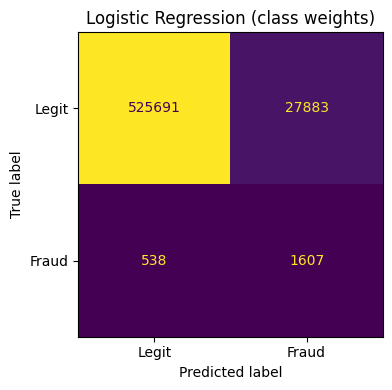

In [11]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Legit', 'Fraud']))
    print(f"AUC-ROC: {roc_auc_score(y_te, y_prob):.4f}")
    
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, 
                                            display_labels=['Legit', 'Fraud'], 
                                            ax=ax, colorbar=False)
    ax.set_title(f"{name}")
    plt.tight_layout()
    plt.show()
    
    return model, roc_auc_score(y_te, y_prob)

results = {}

# Logistic Regression — baseline, class weights
lr, lr_auc = evaluate_model(
    "Logistic Regression (class weights)",
    LogisticRegression(class_weight='balanced', max_iter=1000),
    X_train_scaled, y_train, X_test_scaled, y_test
)
results['LR (class weights)'] = lr_auc

### Logistic Regression Baseline — Findings
Recall of 0.75 means we caught 75% of fraud cases — reasonable. But precision of 0.05 means 95% of our fraud flags were false alarms — 27,883 legitimate transactions wrongly blocked.

This is the fundamental tension in fraud detection. Class weights pushed the model toward catching more fraud, but made it paranoid. A real bank would not accept 27,883 false positives — customers would be furious.

We need a better model.

### XGBoost with SMOTE


Model: XGBoost (SMOTE)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    553574
       Fraud       0.70      0.80      0.75      2145

    accuracy                           1.00    555719
   macro avg       0.85      0.90      0.87    555719
weighted avg       1.00      1.00      1.00    555719

AUC-ROC: 0.9896


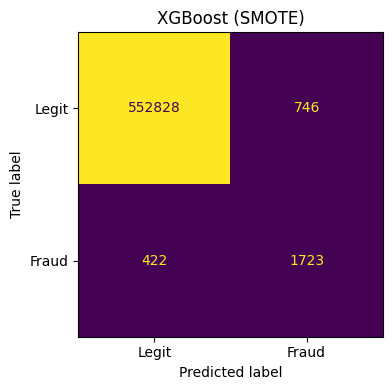

In [12]:
xgb_smote, xgb_smote_auc = evaluate_model(
    "XGBoost (SMOTE)",
    XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    X_smote, y_smote, X_test_scaled, y_test
)
results['XGBoost (SMOTE)'] = xgb_smote_auc

### XGBoost + SMOTE — Findings
A significant improvement. Precision jumped from 0.05 to 0.70 — false alarms dropped from 27,883 to 746. Recall improved to 0.80. AUC-ROC reached 0.9896.

XGBoost handles imbalanced tabular data better than logistic regression because it builds trees that can capture non-linear relationships between features — for example, a high amount at 3am in an unusual category is more suspicious than any of those signals alone.

### XGBoost with Class Weights


Model: XGBoost (class weights)
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00    553574
       Fraud       0.34      0.93      0.49      2145

    accuracy                           0.99    555719
   macro avg       0.67      0.96      0.74    555719
weighted avg       1.00      0.99      0.99    555719

AUC-ROC: 0.9970


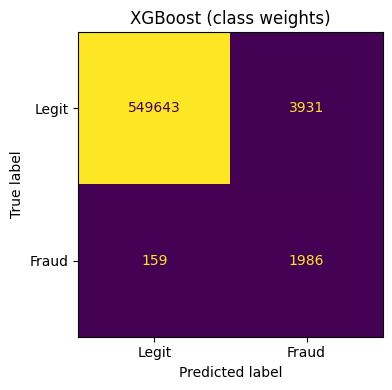

In [13]:
xgb_weights, xgb_weights_auc = evaluate_model(
    "XGBoost (class weights)",
    XGBClassifier(n_estimators=100, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                  random_state=42, eval_metric='logloss'),
    X_train_scaled, y_train, X_test_scaled, y_test
)
results['XGBoost (class weights)'] = xgb_weights_auc

### XGBoost + Class Weights — Findings
Highest AUC-ROC of all models at 0.9970 and recall of 0.93 — it catches 93% of all fraud. But precision drops to 0.34, meaning more false alarms than the SMOTE version.

**This is a business decision, not just a technical one:**
- A bank prioritising catching every fraud case → class weights (high recall)
- A bank prioritising customer experience → SMOTE (fewer false alarms, higher precision)

Neither is objectively better. The right choice depends on the cost of a missed fraud versus the cost of a blocked legitimate transaction.

### Random Forest (SMOTE)


Model: Random Forest (SMOTE)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    553574
       Fraud       0.75      0.75      0.75      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.88      0.88    555719
weighted avg       1.00      1.00      1.00    555719

AUC-ROC: 0.9849


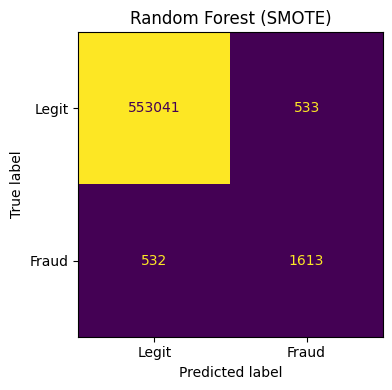

In [14]:
rf_smote, rf_smote_auc = evaluate_model(
    "Random Forest (SMOTE)",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_smote, y_smote, X_test_scaled, y_test
)
results['Random Forest (SMOTE)'] = rf_smote_auc

### Random Forest + SMOTE — Findings
Solid performance — precision 0.75, recall 0.75, F1 0.75 — but XGBoost outperforms it on every metric. Random Forest builds many independent trees and averages them; XGBoost builds trees sequentially, each correcting the errors of the previous one. On tabular data, sequential correction typically wins.

## 7. Model Comparison Summary

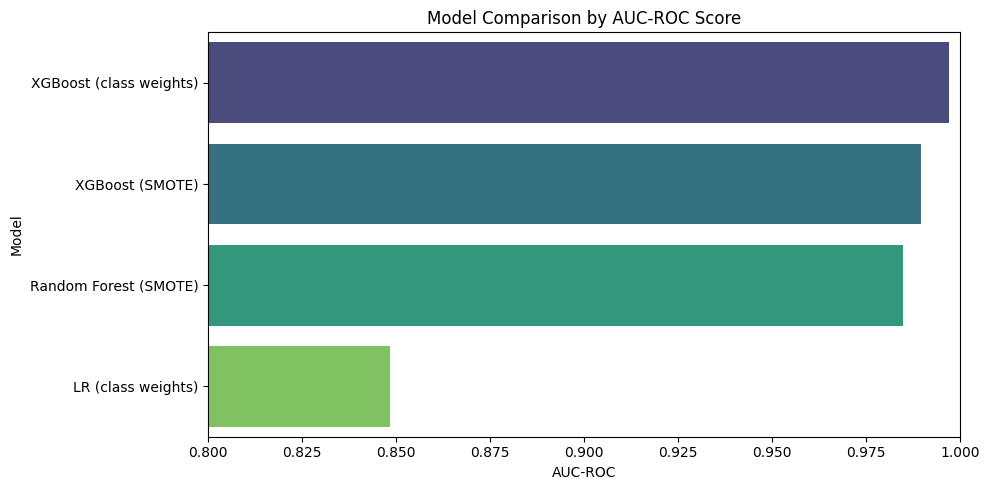

                  Model  AUC-ROC
XGBoost (class weights) 0.997017
        XGBoost (SMOTE) 0.989625
  Random Forest (SMOTE) 0.984871
     LR (class weights) 0.848352


In [15]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': list(results.values())
}).sort_values('AUC-ROC', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='AUC-ROC', y='Model', palette='viridis')
plt.title('Model Comparison by AUC-ROC Score')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

## 8. Explainability with SHAP
SHAP (SHapley Additive exPlanations) answers the question a regulator or auditor would ask: *why did the model flag this transaction?*

In financial services and public sector applications, "the model said so" is not an acceptable answer. SHAP assigns each feature a contribution score for each individual prediction — making the model's reasoning transparent and auditable.

We apply SHAP to XGBoost SMOTE — the best balance of precision and recall.

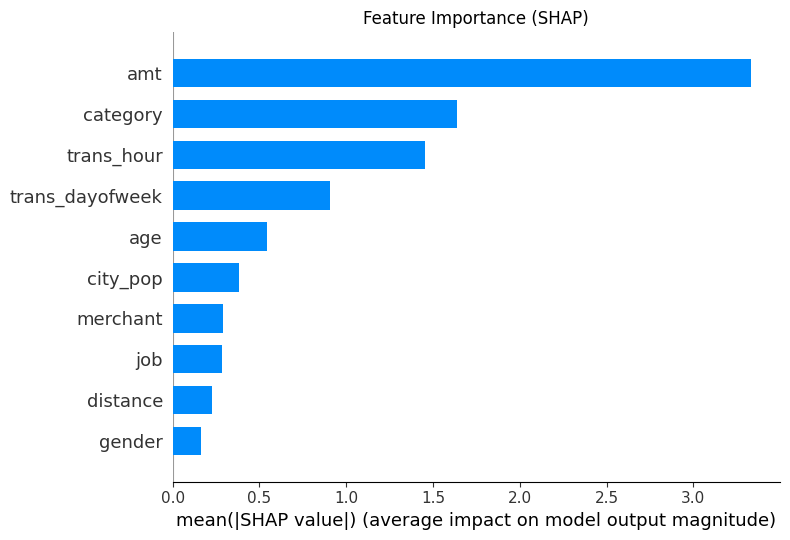

In [16]:
# Use XGBoost SMOTE as our explainability model — best balance of precision and recall
explainer = shap.TreeExplainer(xgb_smote)

# Use a sample of test data — SHAP on 500k rows would take too long
X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)
X_shap_sample = X_test_df.sample(2000, random_state=42)

shap_values = explainer.shap_values(X_shap_sample)

# Summary plot — which features matter most overall
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

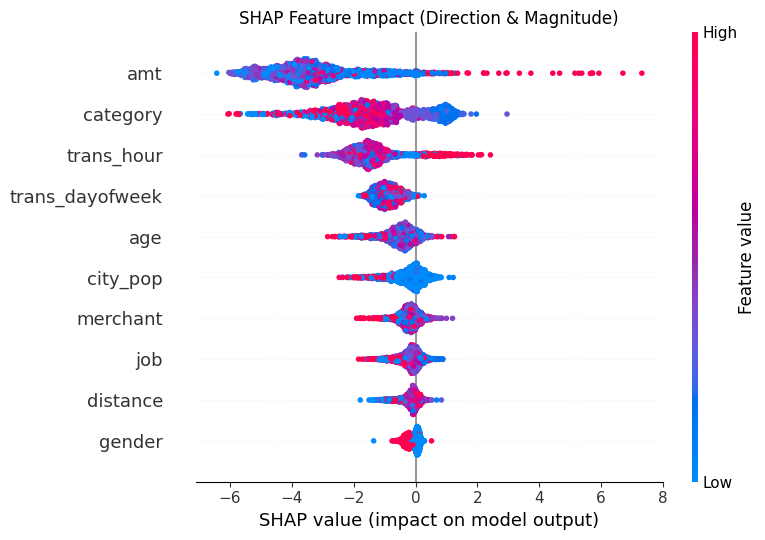

In [17]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("SHAP Feature Impact (Direction & Magnitude)")
plt.tight_layout()
plt.show()

### SHAP Findings
**Feature importance (bar chart):** Transaction amount is by far the strongest fraud signal, followed by merchant category and transaction hour. Features we engineered from raw data — `trans_hour`, `trans_dayofweek`, `distance` — all contributed meaningfully.

**Feature impact (dot plot):** 
- High transaction amounts (red dots) push strongly toward fraud prediction
- Late-night transactions push toward fraud
- Certain merchant categories are strongly associated with fraud
- Smaller city populations show a slight fraud association
- Gender has minimal predictive value — the model learned to mostly ignore it

This level of transparency matters. If a model is penalising people based on gender or age, you need to be able to see that — and justify or correct it. SHAP makes that visible.